In [342]:
import numpy as np
import pandas as pd
data=pd.read_csv('NIFTY_6month.csv')
data.columns = data.columns.str.strip()
data['Date'] = pd.to_datetime(data['Date'], errors='coerce') 
data.set_index('Date', inplace=True) # This removes any leading/trailing spaces
print(data.columns)  # Check the cleaned column names

data.head()


Index(['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)'], dtype='object')


C:\Users\Shahuraje\AppData\Local\Temp\ipykernel_8896\645282373.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'], errors='coerce')


,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
Date,,,,,,
2024-06-10,23319.15,23411.90,23227.15,23259.20,304392368.0,29060.40
2024-06-11,23283.75,23389.45,23206.65,23264.85,305185666.0,29190.91
2024-06-12,23344.45,23441.95,23295.95,23322.95,295630910.0,31795.48
2024-06-13,23480.95,23481.05,23353.90,23398.90,268279841.0,30151.67
2024-06-14,23464.95,23490.40,23334.25,23465.60,223086741.0,25746.34


In [336]:
data.tail()
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)'], dtype='object')

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])


# Check for missing values and handle them if any
data = data.dropna()

data.info()
data.columns

KeyError: 'Date'

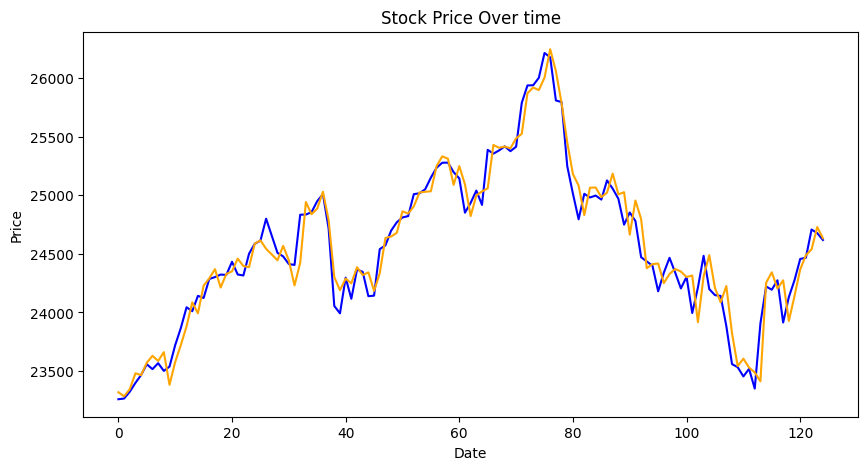

In [319]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(data['Close'],label='Close Price',color='blue')
plt.plot(data['Open'],label='Open Price',color='orange')
plt.title('Stock Price Over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

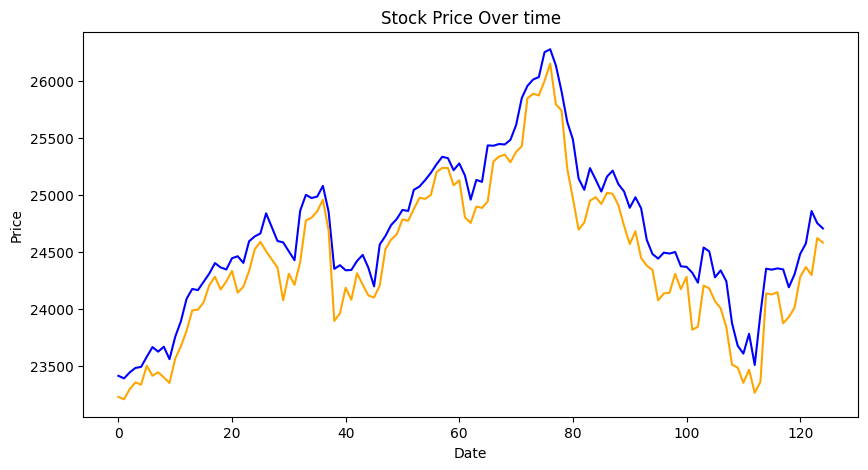

In [320]:
plt.figure(figsize=(10,5))
plt.plot(data['High'],label='High Price',color='blue')
plt.plot(data['Low'],label='Low Price',color='orange')
plt.title('Stock Price Over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

#Check stationary

In [321]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(data['Close'])
print("ADF Statics : ",result[0])
print("p-value : ",result[1])
if(result[1]<=0.05):
    print("The data is stationary.")
else:
     print("The data is not stationary. Differencing might be required.")

ADF Statics :  -2.2172851759858263
p-value :  0.2000318533553696
The data is not stationary. Differencing might be required.


In [322]:
#differencing
data['Close_diff']=data['Close'].diff().dropna()
#Check data is stationary
result=adfuller(data['Close_diff'].dropna())
print("ADF Statics : ",result[0])
print("p-value : ",result[1])
if(result[1]<=0.05):
    print("The data is stationary.")
else:
     print("The data is not stationary. Differencing might be required.")


ADF Statics :  -10.228551640359122
p-value :  5.100160029457689e-18
The data is stationary.


#Autocorrelation and Partial Autocorrelation

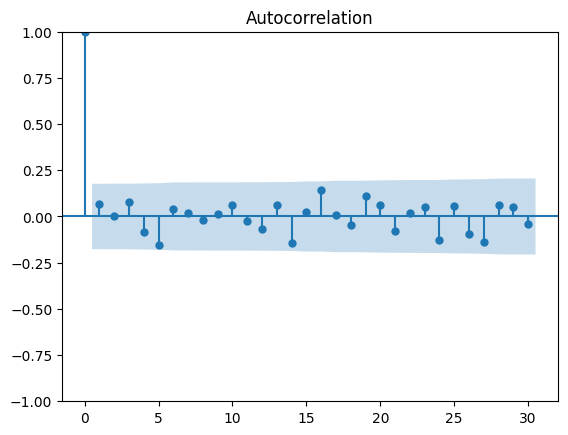

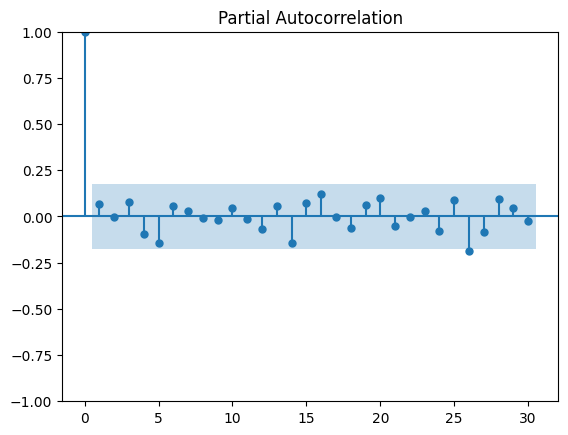

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(data["Close_diff"].dropna(),lags=30)
plot_pacf(data["Close_diff"].dropna(),lags=30)
plt.show()

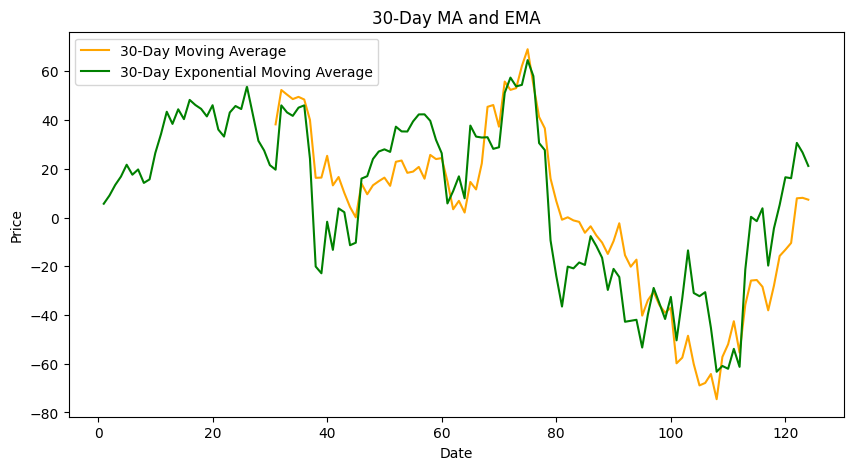

In [ ]:
# Calculate 30-day Moving Average and Exponential Moving Average
data['30_day_MA'] = data['Close_diff'].rolling(window=30).mean()
data['30_day_EMA'] = data['Close_diff'].ewm(span=30, adjust=False).mean()

# Plotting the Moving Averages
plt.figure(figsize=(10, 5))
plt.plot(data['30_day_MA'], label='30-Day Moving Average', color='orange')
plt.plot(data['30_day_EMA'], label='30-Day Exponential Moving Average', color='green')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('30-Day MA and EMA')
plt.legend()
plt.show()



In [325]:
print(data.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded',
       'Turnover (₹ Cr)', 'Close_diff', '30_day_MA', '30_day_EMA'],
      dtype='object')


c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


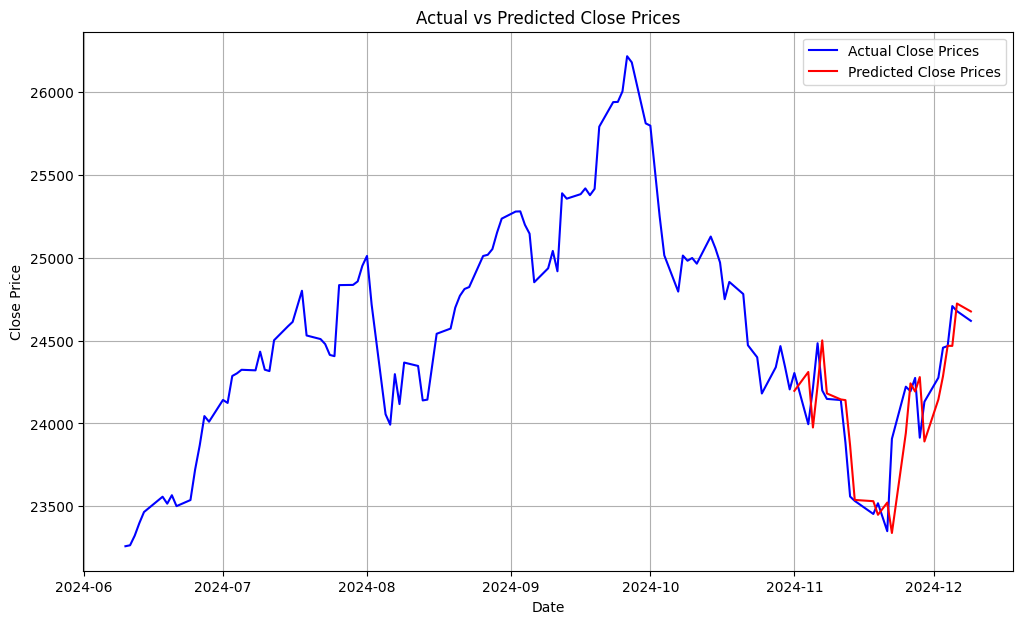

In [368]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Fit the ARIMA model
model = ARIMA(data['Close'], order=(1, 1, 0))
arima_result = model.fit()

# Print summary of the ARIMA model
#print(arima_result.summary())


start_date = pd.to_datetime("2024-11-01")  # Add time component to match data format
end_date = pd.to_datetime("2024-12-09")    # Add time component to match data format

# Check if the dates are within the range of the index
if start_date not in data.index or end_date not in data.index:
    print(f"The start_date or end_date is not found in the data's index. Available dates are:")
    print(data.index.min(), "to", data.index.max())
else:
    # Predict the data for the given date range
    predicted_data = arima_result.predict(start=start_date, end=end_date, typ='levels')

    # Plot the actual and predicted data
    plt.figure(figsize=(12, 7))

    # Plot the actual data
    plt.plot(data.index, data['Close'], label='Actual Close Prices', color='blue')

    # Plot the predicted data (only within the specified date range)
    plt.plot(predicted_data.index, predicted_data, label='Predicted Close Prices', color='red')

    # Title and labels
    plt.title('Actual vs Predicted Close Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.show()


c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


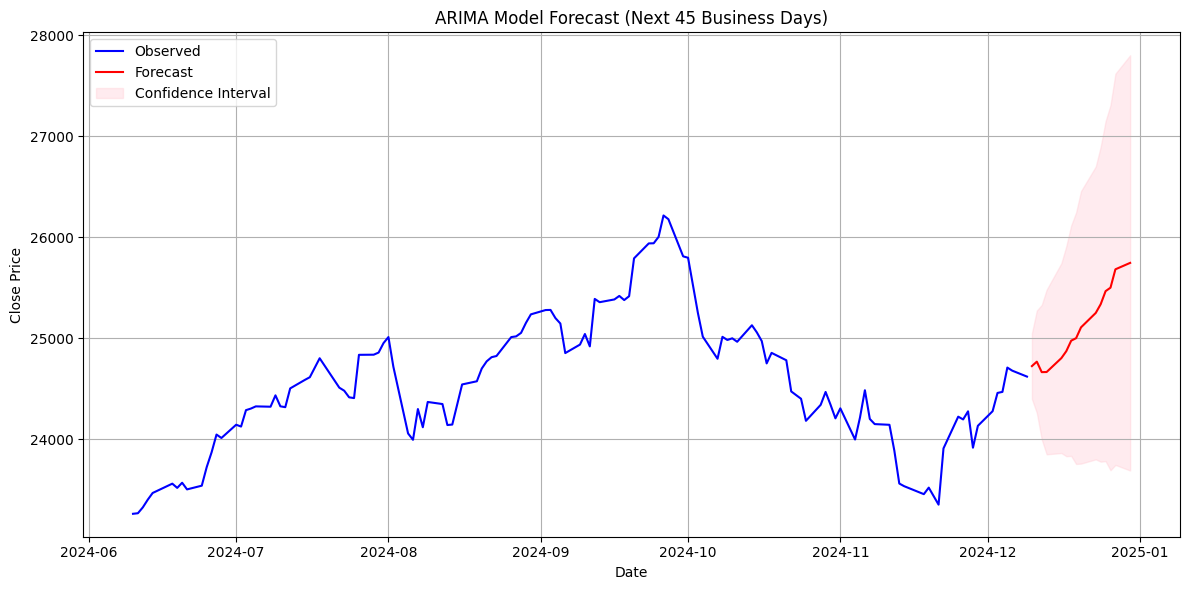

In [327]:
# Forecast the next 45 days
forecast_steps = 15
forecast = arima_result.get_forecast(steps=forecast_steps)

# Create a new index for the forecast
forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='B')

# Extract forecasted values and confidence intervals
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the observed data and forecast
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Observed', color='blue')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(
    forecast_index,
    forecast_ci.iloc[:, 0],  # Lower bound of the confidence interval
    forecast_ci.iloc[:, 1],  # Upper bound of the confidence interval
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)

# Customize the plot
plt.title('ARIMA Model Forecast (Next 45 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [328]:
import numpy as np

# Calculate RMSE manually
train_predictions = arima_result.fittedvalues
rmse = np.sqrt(((train_predictions - data['Close']) ** 2).mean())
print("RMSE:", rmse)



RMSE: 2343.6226141443067


In [329]:
# Save the forecast to a CSV file
forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'Forecast': forecast_mean,
    'Lower_CI': forecast_ci.iloc[:, 0],
    'Upper_CI': forecast_ci.iloc[:, 1]
})
forecast_df.to_csv('forecasted_data.csv', index=False)
df=pd.read_csv('forecasted_data.csv')
df



,Date,Forecast,Lower_CI,Upper_CI
0,2024-12-10,24723.012168,24397.406663,25048.617672
1,2024-12-11,24767.078866,24260.102040,25274.055692
2,2024-12-12,24663.242542,23997.348167,25329.136917
3,2024-12-13,24664.464830,23848.832311,25480.097349
4,2024-12-16,24802.170054,23861.380927,25742.959181
5,2024-12-17,24870.805386,23830.244495,25911.366278
6,2024-12-18,24975.091344,23832.876395,26117.306294
7,2024-12-19,24999.837692,23752.969447,26246.705937
8,2024-12-20,25107.172314,23756.752158,26457.592471
9,2024-12-23,25250.019562,23798.878211,26701.160913


In [330]:
data.tail()

,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr),Close_diff,30_day_MA,30_day_EMA
Date,,,,,,,,,
2024-12-03,24367.50,24481.35,24280.00,24457.15,339470947.0,34228.30,181.10,-13.230000,16.521298
2024-12-04,24488.75,24573.20,24366.30,24467.45,348003156.0,34639.78,10.30,-10.455000,16.119924
2024-12-05,24539.15,24857.75,24295.55,24708.40,361469920.0,40471.33,240.95,7.876667,30.625090
2024-12-06,24729.45,24751.05,24620.50,24677.80,226731303.0,23904.13,-30.60,8.076667,26.675084
2024-12-09,24633.90,24705.00,24580.05,24619.00,248139308.0,25099.79,-58.80,7.320000,21.160563
